## EEG


In [28]:
import re
import math
import json
import numpy as np
import pandas as pd
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
import ptitprince as pt
import matplotlib.pyplot as plt
import seaborn as sns
import ast
%matplotlib inline

In [29]:
def parse_num_list(value):
    if pd.isna(value):
        return None
    text = str(value).strip()
    if not text:
        return None
    if text[0] == "[" and text[-1] == "]":
        text = text[1:-1]
    tokens = text.replace(",", " ").split()
    if not tokens:
        return None
    try:
        return np.asarray(tokens, dtype=np.float32)
    except ValueError:
        return None


def fix_len(arr, n):
    if arr is None:
        return None
    if arr.size == n:
        return arr.astype(np.float32)
    if arr.size > n:
        return arr[:n].astype(np.float32)
    out = np.zeros(n, dtype=np.float32)
    out[: arr.size] = arr
    return out


def power_to_seq(power, n=512):
    if power is None:
        return None
    power = fix_len(power, 8)
    x_old = np.arange(8, dtype=np.float32)
    x_new = np.linspace(0, 7, n, dtype=np.float32)
    return np.interp(x_new, x_old, power).astype(np.float32)

LABELS_JSON_PATH = Path("labels.json")
if not LABELS_JSON_PATH.exists():
    raise FileNotFoundError(f"Missing label mapping file: {LABELS_JSON_PATH}")

_RAW_LABEL_MAP = json.loads(LABELS_JSON_PATH.read_text(encoding="utf-8"))
LABELS = 9
if LABELS == 9:
    # Map to 9 major classes.
    _RAW_LABEL_MAP = _RAW_LABEL_MAP.get("labels_9", {})
elif LABELS == 19:
    # Map to 19 classes (mostly 1-to-1 with raw labels).
    _RAW_LABEL_MAP = _RAW_LABEL_MAP.get("labels_19", {})
else:
    raise ValueError(f"Unsupported number of labels: {LABELS}")

def _resolve_label_once(src: str, label_map: dict, cache: dict) -> str:
    if src in cache:
        return cache[src]

    seen = set()
    cur = src
    while cur in label_map and cur not in seen:
        seen.add(cur)
        cur = label_map[cur]

    cache[src] = cur
    return cur


# Flatten any chained mappings exactly once for O(1) runtime lookup.
_RESOLVED_LABEL_MAP = {}
for _key in _RAW_LABEL_MAP:
    _resolve_label_once(_key, _RAW_LABEL_MAP, _RESOLVED_LABEL_MAP)

# Optional case-insensitive support.
_RESOLVED_LABEL_MAP_LOWER = {k.lower(): v for k, v in _RESOLVED_LABEL_MAP.items()}


def to_major_class(label: str) -> str:
    s = str(label).strip()
    if not s:
        return s

    mapped = _RESOLVED_LABEL_MAP.get(s)
    if mapped is not None:
        return mapped

    mapped = _RESOLVED_LABEL_MAP_LOWER.get(s.lower())
    if mapped is not None:
        return mapped

    # Fast fallback for unseen labels.
    base = re.split(r"[-_]", s)[0]
    base = re.sub(r"\d+$", "", base)
    return base or s

In [30]:
RAW_PATH = Path("EEG/eeg-data.csv")
eeg_data = pd.read_csv(RAW_PATH, converters={"eeg_power": parse_num_list, "raw_values": parse_num_list})
original_size = eeg_data.shape[0]
print(f"Original size of the dataset: {original_size}")

eeg_data = eeg_data[eeg_data.label != 'unlabeled']
print(f"Size of the dataset after removing unlabeled data: {eeg_data.shape[0]}")
eeg_data = eeg_data[eeg_data['signal_quality'] <= 128].copy()
print(f"Data loss percentage: {(1 - eeg_data.shape[0] / original_size) * 100:.2f}%")

# Filtering useful columns 
eeg_data = eeg_data[['id', 'eeg_power', 'raw_values', 'label']]
print("Data shape after dropping unnecessary columns and low quality signals:", eeg_data.shape)

# Power bands
POWER_BANDS = ['delta', 'theta', 'low_alpha', 'high_alpha', 'low_beta', 'high_beta', 'low_gamma', 'mid_gamma']
for i, band in enumerate(POWER_BANDS):
    eeg_data[band] = eeg_data['eeg_power'].apply(lambda x: x[i] if x is not None and len(x) > i else np.nan)
# eeg_data.drop(columns=['eeg_power'], inplace=True)
# print("\nAfter separating power bands:")
print(eeg_data.shape)
display(eeg_data.head(1))

color_map = {}
for label in eeg_data.label.unique():
    color_map[label] = np.random.rand(3,)

# plt.figure(figsize=(10, 10))
# # Compute one scalar per sample to avoid ambiguous comparisons on array-like cells.
# sample_max_power = eeg_data['eeg_power'].apply(lambda x: np.max(x) if x is not None and len(x) else np.nan)
# plt.scatter(eeg_data.id, sample_max_power, c=eeg_data.label.map(color_map))
# plt.xlabel("ID")

print("Columns:", eeg_data.columns)

# def extract_eeg_lists(eeg_power_str): # Runs faster thatn ast.literal_eval() and eval()
#     return [float(n) for n in eeg_power_str.split("[")[1].split("]")[0].split(",")]
# eeg_data.eeg_power = eeg_data.eeg_power.apply(extract_eeg_lists)
# eeg_data.raw_values = eeg_data.raw_values.apply(extract_eeg_lists)


KeyboardInterrupt: 

# FFT of raw EEG values


In [ ]:
# FFT-based features for all rows (from raw_values)
def fft_feature_row(raw_signal, fs_hz):
    feature_template = {
        'fft_dominant_freq_hz': np.nan,
        'fft_spectral_centroid_hz': np.nan,
        'fft_spectral_entropy': np.nan,
        'fft_power_delta': np.nan,
        'fft_power_theta': np.nan,
        'fft_power_alpha': np.nan,
        'fft_power_beta': np.nan,
        'fft_power_gamma': np.nan,
    }

    if raw_signal is None:
        return feature_template

    x = np.asarray(raw_signal, dtype=np.float32)
    if x.ndim != 1 or x.size < 4:
        return feature_template

    x = x - x.mean()
    n = x.size
    freqs = np.fft.rfftfreq(n, d=1.0 / fs_hz)
    psd = (np.abs(np.fft.rfft(x)) ** 2) / n

    if psd.size < 2:
        return feature_template

    # Ignore DC component for descriptive spectral features.
    psd_no_dc = psd.copy()
    psd_no_dc[0] = 0.0
    total_power = float(psd_no_dc.sum())

    if total_power <= 0.0:
        return feature_template

    dominant_idx = int(np.argmax(psd_no_dc))
    dominant_freq = float(freqs[dominant_idx])
    spectral_centroid = float(np.sum(freqs * psd_no_dc) / total_power)

    p = psd_no_dc / total_power
    p = p[p > 0]
    spectral_entropy = float(-(p * np.log2(p)).sum() / np.log2(len(psd_no_dc))) if len(psd_no_dc) > 1 else np.nan

    def band_power(lo_hz, hi_hz):
        mask = (freqs >= lo_hz) & (freqs < hi_hz)
        if not np.any(mask):
            return np.nan
        return float(psd_no_dc[mask].sum())

    return {
        'fft_dominant_freq_hz': dominant_freq,
        'fft_spectral_centroid_hz': spectral_centroid,
        'fft_spectral_entropy': spectral_entropy,
        'fft_power_delta': band_power(0.5, 4.0),
        'fft_power_theta': band_power(4.0, 8.0),
        'fft_power_alpha': band_power(8.0, 13.0),
        'fft_power_beta': band_power(13.0, 30.0),
        'fft_power_gamma': band_power(30.0, 45.0),
    }

if 'FFT_SAMPLE_RATE_HZ' not in globals():
    FFT_SAMPLE_RATE_HZ = 512  # Set to your actual sampling rate if different.

fft_feature_cols = [
    'fft_dominant_freq_hz',
    'fft_spectral_centroid_hz',
    'fft_spectral_entropy',
    'fft_power_delta',
    'fft_power_theta',
    'fft_power_alpha',
    'fft_power_beta',
    'fft_power_gamma',
]

# Safe re-run: remove old FFT feature columns before recomputing.
eeg_data = eeg_data.drop(columns=[c for c in fft_feature_cols if c in eeg_data.columns], errors='ignore')

fft_feature_series = eeg_data['raw_values'].apply(lambda x: fft_feature_row(x, FFT_SAMPLE_RATE_HZ))
fft_feature_df = pd.DataFrame(fft_feature_series.tolist(), index=eeg_data.index)
eeg_data = pd.concat([eeg_data, fft_feature_df], axis=1)

display(eeg_data.head(1))
print(f"Added FFT features for {len(eeg_data)} rows using fs={FFT_SAMPLE_RATE_HZ} Hz")
print("new shape after FFT:", eeg_data.shape)

,id,eeg_power,raw_values,label,delta,theta,low_alpha,high_alpha,low_beta,high_beta,low_gamma,mid_gamma,fft_dominant_freq_hz,fft_spectral_centroid_hz,fft_spectral_entropy,fft_power_delta,fft_power_theta,fft_power_alpha,fft_power_beta,fft_power_gamma
13017,7,"[56887.0, 45471.0, 20074.0, 5359.0, 22594.0, 7...","[99.0, 96.0, 91.0, 89.0, 91.0, 89.0, 87.0, 93....",blinkInstruction,56887.0,45471.0,20074.0,5359.0,22594.0,7867.0,9437.0,3238.0,3.0,4.445884,0.341049,2620048.0,843675.875,151849.84375,97824.140625,19451.005859


Added FFT features for 9954 rows using fs=512 Hz
new shape after FFT: (9954, 20)


In [ ]:
eeg_data.columns

Index(['id', 'eeg_power', 'raw_values', 'label', 'delta', 'theta', 'low_alpha',
       'high_alpha', 'low_beta', 'high_beta', 'low_gamma', 'mid_gamma',
       'fft_dominant_freq_hz', 'fft_spectral_centroid_hz',
       'fft_spectral_entropy', 'fft_power_delta', 'fft_power_theta',
       'fft_power_alpha', 'fft_power_beta', 'fft_power_gamma'],
      dtype='object')

In [ ]:
print(f"Number of IDs: {len(list(eeg_data.id.value_counts().keys()))}")
print(f"Number of labels: {len(list(eeg_data.label.value_counts().keys()))}")

Number of IDs: 30
Number of labels: 67


# Labels


In [ ]:
eeg_data['label'] = eeg_data['label'].map(to_major_class)
eeg_data.reset_index(inplace=True)
print(f"Data shape after collating minor classes into major ones: {eeg_data.shape}")
print(f"Columns: {eeg_data.columns}")
print(f"Unique classes after collating minor classes into major ones: \t{len(eeg_data['label'].unique())}")

Data shape after collating minor classes into major ones: (9954, 21)
Columns: Index(['index', 'id', 'eeg_power', 'raw_values', 'label', 'delta', 'theta',
       'low_alpha', 'high_alpha', 'low_beta', 'high_beta', 'low_gamma',
       'mid_gamma', 'fft_dominant_freq_hz', 'fft_spectral_centroid_hz',
       'fft_spectral_entropy', 'fft_power_delta', 'fft_power_theta',
       'fft_power_alpha', 'fft_power_beta', 'fft_power_gamma'],
      dtype='object')
Unique classes after collating minor classes into major ones: 	9


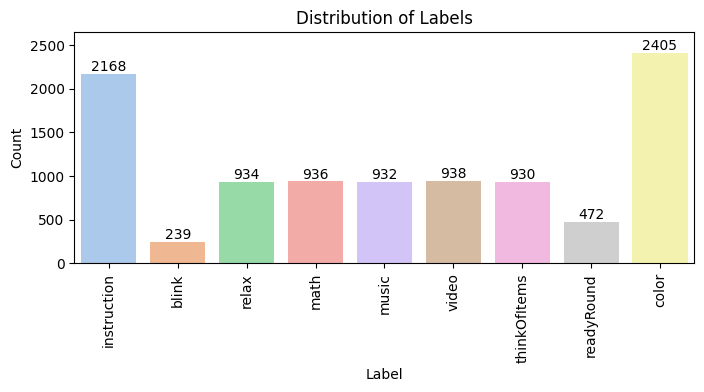

In [ ]:
plt.figure(figsize=(8, 3))
sns.countplot(x='label', data=eeg_data, palette='pastel', hue='label')
for label in eeg_data.label.value_counts().keys():
    count = eeg_data[eeg_data.label == label].shape[0]
    plt.text(label, count, str(count), ha='center', va='bottom', rotation=0)
plt.title('Distribution of Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.ylim(0, max(eeg_data['label'].value_counts()) * 1.1)
plt.show()

In [ ]:
def summarize_vector(values, prefix):
    arr = np.asarray(values, dtype=float)
    if arr.size == 0:
        return {
            f"{prefix}_len": 0.0,
            f"{prefix}_mean": np.nan,
            f"{prefix}_std": np.nan,
            f"{prefix}_min": np.nan,
            f"{prefix}_max": np.nan,
            f"{prefix}_median": np.nan,
            f"{prefix}_q05": np.nan,
            f"{prefix}_q95": np.nan,
            f"{prefix}_abs_mean": np.nan,
            f"{prefix}_clip_ratio": np.nan,
        }

    return {
        f"{prefix}_len": float(arr.size),
        f"{prefix}_mean": float(arr.mean()),
        f"{prefix}_std": float(arr.std()),
        f"{prefix}_min": float(arr.min()),
        f"{prefix}_max": float(arr.max()),
        f"{prefix}_median": float(np.median(arr)),
        f"{prefix}_q05": float(np.quantile(arr, 0.05)),
        f"{prefix}_q95": float(np.quantile(arr, 0.95)),
        f"{prefix}_abs_mean": float(np.mean(np.abs(arr))),
        f"{prefix}_clip_ratio": float(np.mean(np.abs(arr) >= 2047.0)),
    }

# Sample power and raw values


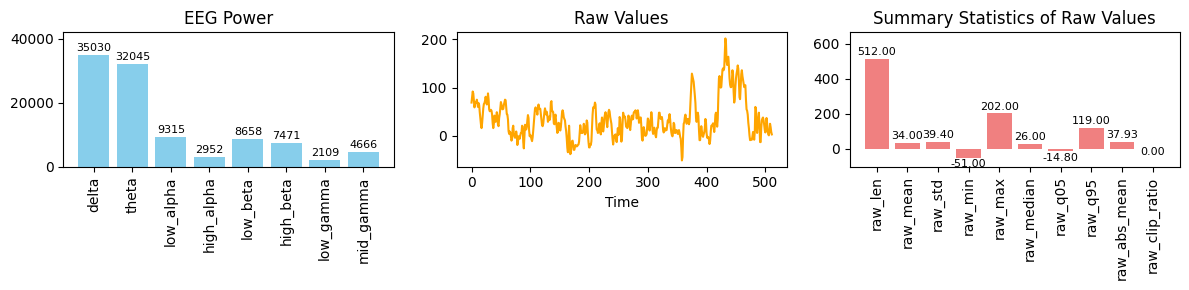

In [ ]:
random_index = np.random.choice(eeg_data.index)
fig, axs = plt.subplots(1, 3, figsize=(12, 3))

axs[0].bar(POWER_BANDS, eeg_data.loc[random_index, POWER_BANDS], color='skyblue')
for p in axs[0].patches:
    axs[0].annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=8, color='black', xytext=(0, 5),
                    textcoords='offset points')
axs[0].set_title('EEG Power')
axs[0].set_ylim(0, max(eeg_data.loc[random_index, POWER_BANDS]) * 1.2)
axs[0].set_xticks(range(len(POWER_BANDS)))
axs[0].set_xticklabels(POWER_BANDS, rotation=90)

axs[1].plot(eeg_data.loc[random_index, 'raw_values'], label='Raw Values', color='orange')
axs[1].set_title('Raw Values')
axs[1].set_xlabel('Time')

raw_features = summarize_vector(eeg_data.loc[random_index, 'raw_values'], 'raw')
axs[2].bar(raw_features.keys(), raw_features.values(), color='lightcoral')
for i, value in enumerate(raw_features.values()):
    axs[2].text(i, value + math.copysign(10, value),
                f'{value:.2f}', ha='center', va='bottom' if value > 0 else 'top', fontsize=8)
axs[2].set_title('Summary Statistics of Raw Values')
axs[2].set_xticks(range(len(raw_features.keys())))
axs[2].set_xticklabels(raw_features.keys(), rotation=90)
axs[2].set_ylim(min(raw_features.values()) * 2, max(raw_features.values()) * 1.3)

plt.tight_layout()
plt.show()

In [ ]:
raw_features

{'raw_len': 512.0,
 'raw_mean': 34.001953125,
 'raw_std': 39.404131040543234,
 'raw_min': -51.0,
 'raw_max': 202.0,
 'raw_median': 26.0,
 'raw_q05': -14.799999999999997,
 'raw_q95': 119.0,
 'raw_abs_mean': 37.927734375,
 'raw_clip_ratio': 0.0}

In [ ]:
print(f"{len(POWER_BANDS)} power bands + {len(fft_feature_cols)} FFT features + {len(raw_features)} raw value summary features = {len(POWER_BANDS) + len(fft_feature_cols) + len(raw_features)} total features")

8 power bands + 8 FFT features + 10 raw value summary features = 26 total features


In [ ]:
for stat in raw_features.keys():
    eeg_data[f'{stat}'] = eeg_data['raw_values'].apply(lambda x: summarize_vector(x, 'raw')[stat] if x is not None else np.nan)

print("Shape after adding raw value features:", eeg_data.shape)
print("Columns after adding raw value features:", eeg_data.columns)

Shape after adding raw value features: (9954, 31)
Columns after adding raw value features: Index(['index', 'id', 'eeg_power', 'raw_values', 'label', 'delta', 'theta',
       'low_alpha', 'high_alpha', 'low_beta', 'high_beta', 'low_gamma',
       'mid_gamma', 'fft_dominant_freq_hz', 'fft_spectral_centroid_hz',
       'fft_spectral_entropy', 'fft_power_delta', 'fft_power_theta',
       'fft_power_alpha', 'fft_power_beta', 'fft_power_gamma', 'raw_len',
       'raw_mean', 'raw_std', 'raw_min', 'raw_max', 'raw_median', 'raw_q05',
       'raw_q95', 'raw_abs_mean', 'raw_clip_ratio'],
      dtype='object')


# OR Load the fully-featured, cleaned dataset:

In [ ]:
eeg_data.to_csv("EEG/eeg_data_with_features.csv", index=False)
eeg_data = pd.read_csv("EEG/eeg_data_with_features.csv", converters={"eeg_power": parse_num_list, "raw_values": parse_num_list})
print("Shape after reloading from CSV:", eeg_data.shape)

Row index: 1450


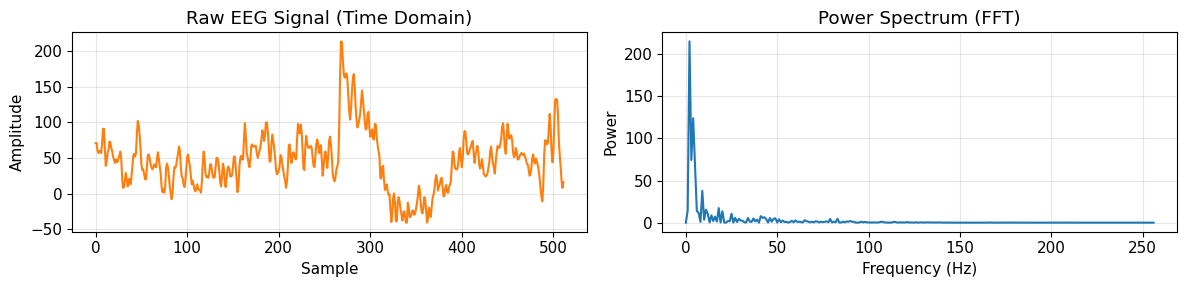

In [ ]:
def compute_fft(raw_signal, fs_hz):
    x = np.asarray(raw_signal, dtype=np.float32)
    if x.ndim != 1 or x.size < 2:
        raise ValueError("raw_signal must be a 1D array-like with at least 2 samples.")

    # Remove DC offset so low-frequency energy is easier to interpret.
    x = x - x.mean()
    n = x.size

    freqs = np.fft.rfftfreq(n, d=1.0 / fs_hz)
    spectrum = np.fft.rfft(x)
    amplitude = np.abs(spectrum) / n
    power = amplitude ** 2
    return freqs, amplitude, power

random_index = np.random.choice(eeg_data.index)
raw_signal = eeg_data.loc[random_index, 'raw_values']

if 'FFT_SAMPLE_RATE_HZ' not in globals():
    FFT_SAMPLE_RATE_HZ = 512  # Set to your actual sampling rate if different.

freqs, amplitude, power = compute_fft(raw_signal, FFT_SAMPLE_RATE_HZ)
fft_columns = [
        'fft_dominant_freq_hz', 
        'fft_spectral_centroid_hz',
        'fft_spectral_entropy',
        'fft_power_delta', 
        'fft_power_theta',
        'fft_power_alpha',
        'fft_power_beta',
        'fft_power_gamma'
    ]

print(f"Row index: {random_index}")
# print(f"Dominant frequency: {eeg_data['fft_dominant_freq_hz'][random_index]:.2f} Hz")

fig, axs = plt.subplots(1,2, figsize=(12, 3))
axs[0].plot(raw_signal, color='tab:orange')
axs[0].set_title('Raw EEG Signal (Time Domain)')
axs[0].set_xlabel('Sample')
axs[0].set_ylabel('Amplitude')
axs[0].grid(alpha=0.3)

axs[1].plot(freqs,power, color='tab:blue')
axs[1].set_title('Power Spectrum (FFT)')
axs[1].set_xlabel('Frequency (Hz)')
axs[1].set_ylabel('Power')
# axs[1].set_xlim(0, FFT_SAMPLE_RATE_HZ / 2)
axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### To further preprocess the data, all these raw value stats could be considered as additional features (new columns).

### Then, train/val/test split for some initial model development and evaluation.

### Class (label) balance is very important, also subject leakage!

### More advanced models (CNN, RNN, Transformer) could be also developed without these features.


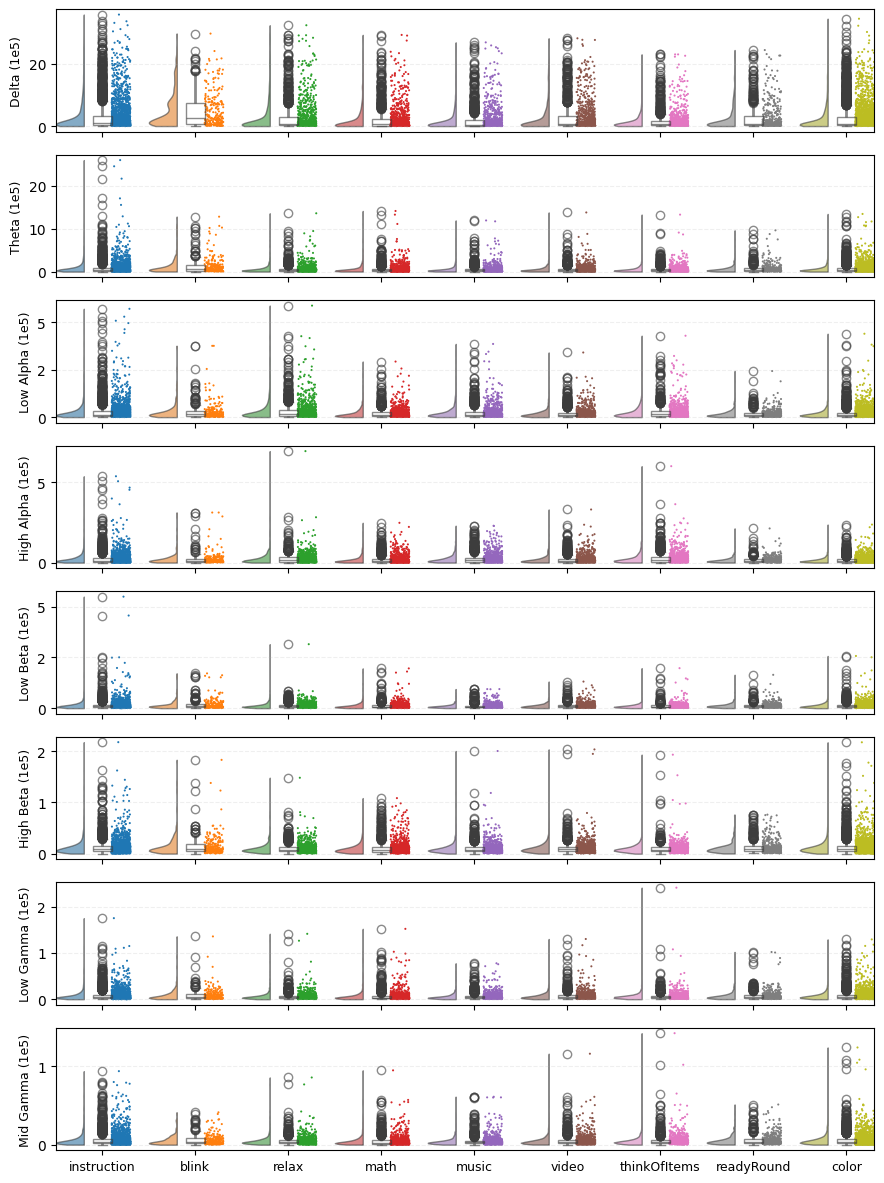

In [ ]:
def plot_power_distribution(data=eeg_data, large=True):
    classes = data['label'].dropna().unique().tolist()
    fig, axs = plt.subplots(len(POWER_BANDS), 1, figsize=(9, 12), sharex=True)

    plt.rcParams.update({'font.size': 12})

    for i, ax in enumerate(axs):
        rows = []
        for cls in classes:
            class_data = data[data['label'] == cls]
            if class_data.empty:
                continue
            power_values = np.array(class_data['eeg_power'].tolist(), dtype=float)
            if power_values.size == 0:
                continue
            band_values = power_values[:, i]
            rows.extend([{'label': cls, 'value': v} for v in band_values])

        if not rows:
            ax.set_title(f"{POWER_BANDS[i].capitalize()} (no data)")
            continue

        band_df = pd.DataFrame(rows)

        pt.RainCloud(
            data=band_df,
            x='label',
            y='value',
            orient='v',
            hue='label',
            # palette='Set2',
            width_viol=0.6,
            width_box=0.2,
            move=0.2,
            alpha=0.6,
            point_size=1.5,
            ax=ax
        )

        # ax.set_title(f"{POWER_BANDS[i].capitalize()} Power Distribution by Class")
        ax.set_xlabel('')
        ax.set_ylabel(f'{POWER_BANDS[i].replace('_', ' ').title()}', fontsize=9)
        if large:ax.set_ylabel(f'{POWER_BANDS[i].replace('_', ' ').title()} (1e5)')
        ax.grid(axis='y', alpha=0.2, linestyle='--')

    # Format all y-axes to display in 1e5 units
    from matplotlib.ticker import FuncFormatter
    def format_1e5(x, pos):
        return f'{x/1e5:.0f}'

    for ax in axs:
        if large:
            ax.yaxis.set_major_formatter(FuncFormatter(format_1e5))

    axs[-1].tick_params(axis='x', rotation=0, labelsize=9)
    plt.tight_layout()
    plt.show()
plot_power_distribution()

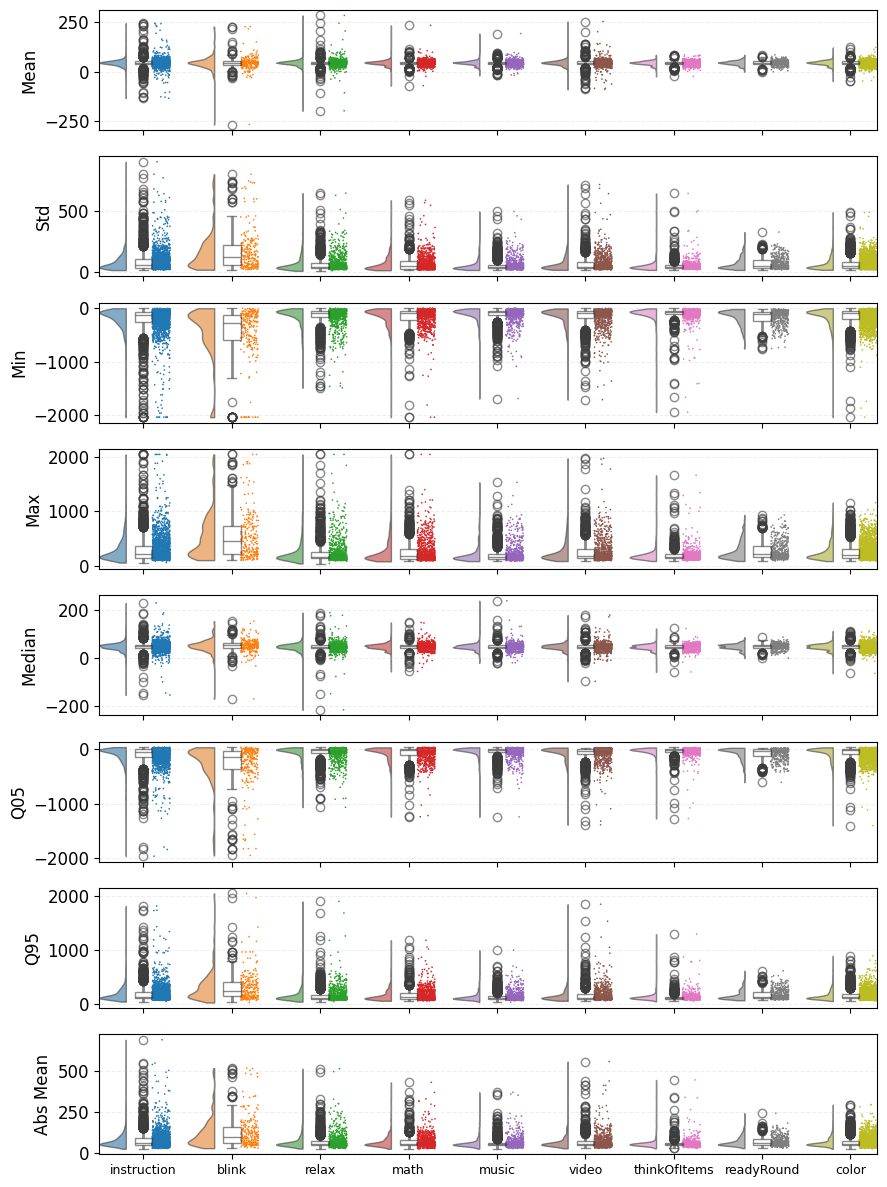

In [ ]:
def plot_raw_stats_distribution(data=eeg_data, columns=None, ncols=1, figsize_per_panel=(7, 3.5)):
    if columns is None:
        inferred_cols = [f"{stat}" for stat in raw_features.keys()]
        # Exclude len and clip_ratio as they are all identical (512, 0.0, respectively) across samples and classes.
        columns = [col for col in inferred_cols if col in data.columns][1:-1] 

    if not columns:
        raise ValueError("No raw-stat feature columns were found to plot.")

    classes = data['label'].dropna().unique().tolist()
    n_panels = len(columns)
    nrows = math.ceil(n_panels / ncols)
    fig, axs = plt.subplots(
        nrows,
        ncols,
        # figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
        figsize=(9,12),
        # squeeze=False,
        sharex=True
    )
    axs = axs.flatten()

    plt.rcParams.update({'font.size': 11})

    for i, feature in enumerate(columns):
        ax = axs[i]
        rows = []

        for cls in classes:
            class_values = data.loc[data['label'] == cls, feature].dropna().astype(float)
            rows.extend({'label': cls, 'value': value} for value in class_values)

        if not rows:
            ax.set_title(f"{feature} (no data)")
            ax.axis('off')
            continue

        feature_df = pd.DataFrame(rows)

        pt.RainCloud(
            data=feature_df,
            x='label',
            y='value',
            orient='v',
            hue='label',
            width_viol=0.6,
            width_box=0.2,
            move=0.2,
            alpha=0.6,
            point_size=1.2,
            ax=ax
        )

        pretty_name = feature.removeprefix('raw_').replace('_', ' ').title()
        # ax.set_title(pretty_name)
        ax.set_xlabel('')
        ax.set_ylabel(pretty_name)
        ax.grid(axis='y', alpha=0.2, linestyle='--')
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    for ax in axs[n_panels:]:
        ax.axis('off')

    last_row_start = max(0, (nrows - 1) * ncols)
    for ax in axs[last_row_start:last_row_start + ncols]:
        if ax.has_data():
            ax.tick_params(axis='x', rotation=0, labelsize=9)

    plt.tight_layout()
    plt.show()
plot_raw_stats_distribution()

In [ ]:
eeg_data['label'].unique()

array(['instruction', 'blink', 'relax', 'math', 'music', 'video',
       'thinkOfItems', 'readyRound', 'color'], dtype=object)

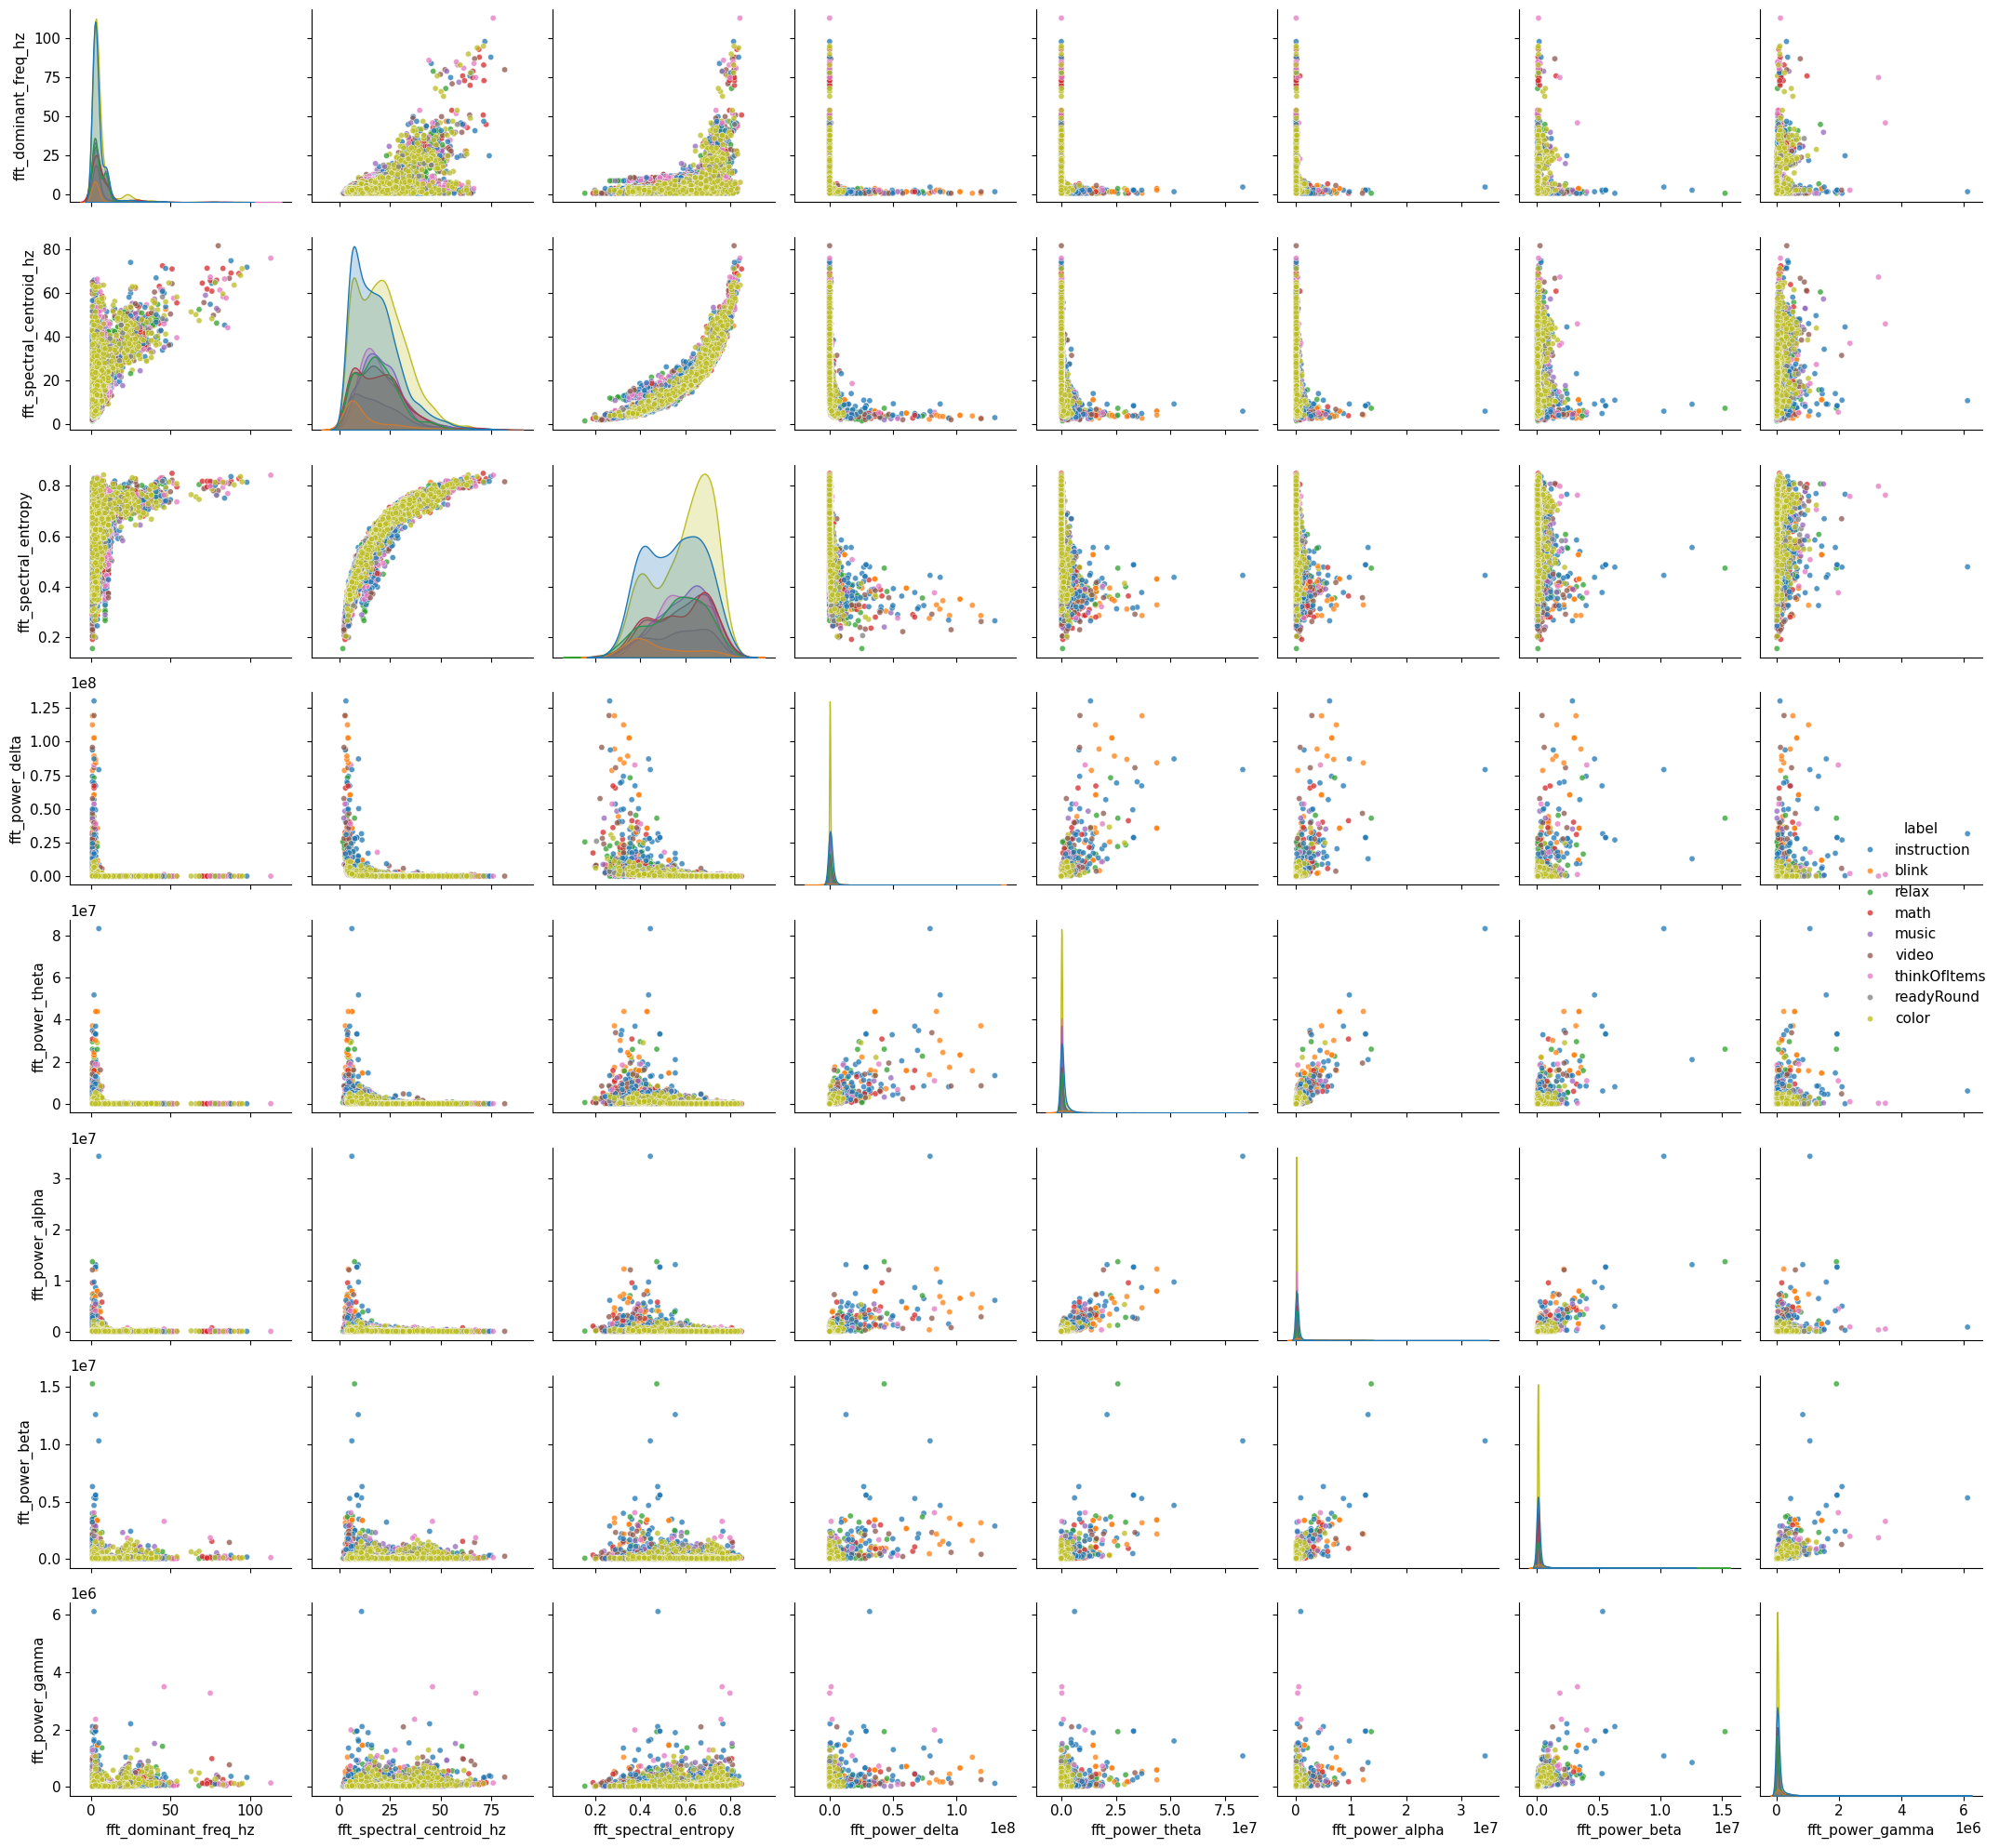

In [43]:
feature_cols =  ['label'] + fft_columns # + POWER_BANDS + list(raw_features.keys())[1:-1]
sns.pairplot(data=eeg_data[feature_cols], hue='label', diag_kind='kde', plot_kws={'alpha':0.75, 's':20})
# plt.suptitle('Raw Stats vs Power Bands Scatter Matrix', y=1.01)
plt.tight_layout()
# plt.savefig('scatter_matrix_raw_vs_power_bands.pdf', bbox_inches='tight', dpi=300, transparent=True, facecolor='white', format='pdf')
plt.show()
# plt.close()

## Normalizing the class imbalanceness

### Method 1. Simply assigning the 1-complement proportion of each class (naive method).

### Method 2. Normalizing the class weights from Mehotd 1 with (C - 1), where C is the number of classes.

### Method 3: Normlized inverse of class proportions (reverse distribution sould be observed!).


In [ ]:
num_classes = len(eeg_data['label'].unique())
# print(f"Number of unique classes: {num_classes}")
sample_per_class = eeg_data['label'].value_counts()
class_proportions = eeg_data['label'].value_counts(normalize=True)

# Method 1: class weight = 1 - class proportion 
complementary_class_weights = (1.0 - class_proportions)

# Method 2: class weight = (1 - class proportion) / (num_classes - 1)
normalized_class_weights = complementary_class_weights / (num_classes - 1)

print(f'Mean of complementary: {complementary_class_weights.mean():.4f} \t STD of complementary: {complementary_class_weights.std():.4f}')
print(f'Mean of normalized   : {normalized_class_weights.mean():.4f} \t STD of normalized   : {normalized_class_weights.std():.4f}')

# Method 3: class weight = 1 / class proportion
normalized_inverse_proportions = 1.0 / (class_proportions + 1e-8)
normalized_inverse_proportions = normalized_inverse_proportions / normalized_inverse_proportions.sum()

# print("Class proportions:\n", class_proportions)
# print("Class weights:\n", normalized_class_weights)

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].bar(sample_per_class.index, sample_per_class.values, color='skyblue')
axs[0].set_title('Samples per Class')
axs[0].set_xticks(ticks=range(len(sample_per_class.index)))
axs[0].set_xticklabels(labels=sample_per_class.index, rotation=90)

axs[1].bar(complementary_class_weights.index, complementary_class_weights.values, color='salmon', alpha=0.3, label='Complementary')
axs[1].bar(normalized_class_weights.index, normalized_class_weights.values, color='skyblue', label='Normalized')
axs[1].set_title('Complementary and Normalized Class Weights')
axs[1].set_xticks(ticks=range(len(normalized_class_weights.index)))
axs[1].set_xticklabels(labels=normalized_class_weights.index, rotation=90)
axs[1].legend(loc='right')

axs[2].bar(normalized_inverse_proportions.index, normalized_inverse_proportions.values, color='skyblue')
axs[2].set_title('Normalized Inverse Class Proportions')
axs[2].set_xticks(ticks=range(len(normalized_inverse_proportions.index)))
axs[2].set_xticklabels(labels=normalized_inverse_proportions.index, rotation=90)

plt.tight_layout()
plt.show()

# An MLP model for classification


In [ ]:
# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Extract features (8 power bands) and target (class label)
X = np.array(eeg_data['eeg_power'].tolist(), dtype=np.float32)
y = eeg_data['label'].values
subject_ids = eeg_data['id'].values

# Encode class labels to numeric values
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)

print(f"Feature shape: {X.shape}")
print(f"Number of classes: {num_classes}")
print(f"Class labels: {label_encoder.classes_}")
print(f"Total unique subjects: {len(np.unique(subject_ids))}")

# Train-val split per subject (80/20, no leakage) → 24 train / 6 val subjects
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(X, y_encoded, groups=subject_ids))

X_train, X_val = X[train_idx], X[val_idx]
y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]
subjects_train = np.unique(subject_ids[train_idx])
subjects_val   = np.unique(subject_ids[val_idx])

print(f"\nTrain-Val split (per subject, no leakage):")
print(f"  Train: {len(subjects_train)} subjects  ({len(train_idx)} rows)")
print(f"  Val:   {len(subjects_val)} subjects  ({len(val_idx)} rows)")

# Complementary class weights from training set only
class_weights = torch.tensor(
    [1.0 - float((y_train == i).sum()) / len(y_train) for i in range(num_classes)],
    dtype=torch.float32
)
class_weights = (class_weights / class_weights.sum() * num_classes).to(device)

print(f"\nComplementary Class Weights:")
for i, lbl in enumerate(label_encoder.classes_):
    print(f"  {lbl}: {class_weights[i].item():.4f}")

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit on train only
X_val   = scaler.transform(X_val)         # apply same transform to val

# Tensors (kept on CPU; DataLoader handles batching)
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val,   dtype=torch.long)

# MLP model
class EEGClassifier(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size1), nn.ReLU(), nn.Dropout(0.45),
            nn.Linear(hidden_size1, hidden_size2), nn.ReLU(), nn.Dropout(0.45),
            nn.Linear(hidden_size2, num_classes)
        )
    def forward(self, x):
        return self.net(x)

model     = EEGClassifier(8, 32, 16, num_classes).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-3)

batch_size   = 32
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),   batch_size=batch_size, shuffle=False)

print(f"\nModel:\n{model}")
print(f"Device: {device}")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")    


## Diagnostics: class distribution per split & sklearn baselines


In [ ]:
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# ── Class distribution: train vs val ─────────────────────────────
train_labels = label_encoder.inverse_transform(y_train)
val_labels   = label_encoder.inverse_transform(y_val)

train_dist = pd.Series(train_labels).value_counts().sort_index()
val_dist   = pd.Series(val_labels).value_counts().sort_index()

dist_df = pd.DataFrame({'train': train_dist, 'val': val_dist}).fillna(0).astype(int)
print("Class distribution (train vs val):")
print(dist_df.to_string())
missing_in_val = [c for c in label_encoder.classes_ if c not in val_labels]
if missing_in_val:
    print(f"\n⚠️  Classes absent from val set: {missing_in_val}")
    print("   F1-macro will be penalised for these — consider GroupKFold for stable evaluation.")

# ── Majority-class baseline ───────────────────────────────────────
majority = pd.Series(y_train).value_counts().idxmax()
majority_preds = np.full(len(y_val), majority)
print(f"\nMajority-class baseline  Val F1-macro: {f1_score(y_val, majority_preds, average='macro', zero_division=0):.4f}")

# ── Random Forest ─────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=300, max_depth=None, class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_val)
rf_f1 = f1_score(y_val, rf_preds, average='macro', zero_division=0)
print(f"Random Forest            Val F1-macro: {rf_f1:.4f}")

# ── Gradient Boosting ─────────────────────────────────────────────
gb = GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                                 subsample=0.8, random_state=42)
gb.fit(X_train, y_train)
gb_preds = gb.predict(X_val)
gb_f1 = f1_score(y_val, gb_preds, average='macro', zero_division=0)
print(f"Gradient Boosting        Val F1-macro: {gb_f1:.4f}")

# ── Best baseline: full report + confusion matrix ─────────────────
best_preds, best_name = (rf_preds, "Random Forest") if rf_f1 >= gb_f1 else (gb_preds, "Gradient Boosting")
print(f"\nClassification Report — {best_name} (Val):")
print(classification_report(y_val, best_preds, target_names=label_encoder.classes_, zero_division=0))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_val, best_preds,
    display_labels=label_encoder.classes_,
    xticks_rotation=90,
    ax=ax,
    colorbar=False
)
ax.set_title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.show()

# ── Feature importance (Random Forest) ───────────────────────────
fig, ax = plt.subplots(figsize=(6, 3))
importances = pd.Series(rf.feature_importances_, index=POWER_BANDS).sort_values()
importances.plot.barh(ax=ax, color='steelblue')
ax.set_title("Random Forest — Feature Importances")
ax.set_xlabel("Mean decrease in impurity")
plt.tight_layout()
plt.show()

In [ ]:
normal_df = pd.DataFrame(columns=["eeg_power", "label"])
for i in range(X_train.shape[0]):
    normal_df.loc[i] = {
        "eeg_power": X_train[i],
        "label": label_encoder.inverse_transform([y_train[i]])[0]
    }
plot_power_distribution(data=normal_df, large=False)

# Training loop


In [ ]:
from sklearn.metrics import f1_score, classification_report

num_epochs = 80
best_f1 = -1.0
best_weights = None
best_epoch = 0
patience = 20
patience_counter = 0
min_delta = 1e-4

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=4,
    min_lr=1e-5
)

history = {
    'train_loss': [],
    'val_loss': [],
    'train_f1': [],
    'val_f1': [],
    'lr': []
}

for epoch in range(1, num_epochs + 1):
    # Training
    model.train()
    train_loss = 0.0
    train_preds, train_targets = [], []

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item() * len(yb)
        train_preds.extend(logits.argmax(dim=1).detach().cpu().numpy())
        train_targets.extend(yb.detach().cpu().numpy())

    train_loss /= len(y_train)
    train_f1 = f1_score(train_targets, train_preds, average='macro', zero_division=0)

    # Validation
    model.eval()
    val_loss = 0.0
    val_preds, val_targets = [], []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            val_loss += loss.item() * len(yb)
            val_preds.extend(logits.argmax(dim=1).cpu().numpy())
            val_targets.extend(yb.cpu().numpy())

    val_loss /= len(y_val)
    val_f1 = f1_score(val_targets, val_preds, average='macro', zero_division=0)

    scheduler.step(val_f1)
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)
    history['lr'].append(current_lr)

    improved = val_f1 > (best_f1 + min_delta)
    if improved:
        best_f1 = val_f1
        best_epoch = epoch
        best_weights = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 5 == 0 or epoch == 1 or improved:
        print(
            f"Epoch {epoch:3d}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f}  Train F1: {train_f1:.4f} | "
            f"Val Loss: {val_loss:.4f}  Val F1: {val_f1:.4f} | "
            f"LR: {current_lr:.2e}" + ("  <- best" if improved else "")
        )

    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch} (best epoch: {best_epoch}, best val F1-macro: {best_f1:.4f})")
        break

if best_weights is None:
    best_weights = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

model.load_state_dict({k: v.to(device) for k, v in best_weights.items()})
print(f"\nBest Val F1-macro: {best_f1:.4f} at epoch {best_epoch} (model restored)")

# Final report on validation set using best checkpoint
model.eval()
final_preds, final_targets = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)
        logits = model(xb)
        final_preds.extend(logits.argmax(dim=1).cpu().numpy())
        final_targets.extend(yb.numpy())

final_val_f1 = f1_score(final_targets, final_preds, average='macro', zero_division=0)
print(f"Final Val F1-macro (best checkpoint): {final_val_f1:.4f}")

print("\nClassification Report (Validation Set):")
print(classification_report(
    final_targets,
    final_preds,
    target_names=label_encoder.classes_,
    zero_division=0
))

fig, axs = plt.subplots(1, 3, figsize=(12, 3))

axs[0].plot(history['train_loss'], label='Train')
axs[0].plot(history['val_loss'], label='Val')
axs[0].set_title('Loss')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Cross-Entropy Loss')
axs[0].legend()
axs[0].grid(alpha=0.3)

axs[1].plot(history['train_f1'], label='Train')
axs[1].plot(history['val_f1'], label='Val')
axs[1].set_title('F1-Macro')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('F1-Macro')
axs[1].legend()
axs[1].grid(alpha=0.3)

axs[2].plot(history['lr'])
axs[2].set_title('Learning Rate')
axs[2].set_xlabel('Epoch')
axs[2].set_ylabel('LR')
axs[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()